## 1. What this notebook computes

The field dirac16complex is **quantised**: its 16 components become *operators*,
and the charge-conjugation maps of the previous notebooks of this chapter act on
operators. Exchanging two operators is not free: it costs a sign and leaves a
number behind (their anticommutator). This notebook computes, on an explicit
computer model of the quantum states, what the two charge-conjugation maps do to
the scalar $S = \Psi^\dagger C\Psi$ and to the eight currents $J^a =
\Psi^\dagger(-iC\gamma^a)\Psi$ of the quantised field. It

1. builds the operators of fermions from zero (two modes, then sixteen modes with
   $2^{16} = 65536$ states);
2. realises the quantised field of the Revision record for one momentum without
   extra-time part (the record's example $m = 3$, momentum 4 along $x1$, energy
   $E = 5$), with the Hilbert adjoint $\chi$ and the canonical conjugate
   $\Psi^\dagger = \chi B$, and checks $\{\Psi_A, \chi_C\} = \delta_{AC}$ and
   $\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$;
3. shows why $\Psi^\dagger$ cannot be the Hilbert adjoint (an indefinite, Krein,
   inner product is needed), as the record proves;
4. reproduces the recorded vacuum energy $-8E = -40$, the energies $+5$ and the
   charges $\pm 1$ of the 16 quanta, and the expectation-value rule;
5. applies the two conjugations $\Psi \to M\Psi^{\dagger T}$ with $M = 1$ (the
   type of $\mathcal{C}_+$) and $M = \Gamma$ (the type of $\mathcal{C}_-$) to the
   operators: of the two, only $M = \Gamma$ keeps the canonical rule;
6. computes every conjugated bilinear as an operator: it is the original bilinear
   times a sign, plus a constant; the sign is the one of the classical
   *anticommuting* components; **normal ordering** removes the constant and
   nothing else.

Eight teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 05e (The quantised field: reordering operators, normal ordering and the
conjugated bilinears) is the file
`Revision/textbook/notebooks/05e_quantum_bilinears.ipynb` of the repository Dirac_claude.
It builds the fermion Fock space of 16 modes (65536 states) of the good-sector example of
the Revision record, realises the quantised field with the Hilbert adjoint chi and the
canonical conjugate Psi^dagger = chi B, checks the rules {Psi_A, chi_C} = delta_AC and
{Psi_A, Psi^dagger_C} = B_AC, shows why Psi^dagger cannot be the Hilbert adjoint,
reproduces the recorded vacuum energy, the energies and charges of the 16 quanta and the
expectation-value rule, applies the two conjugations Psi to M Psi^(dagger T) with M = 1
and M = Gamma to the operators, and computes exactly how the scalar S and the eight
currents J^a change as operators: by the sign of the classical anticommuting components
plus a constant, which normal ordering removes. Eight teaching plots. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other packages
run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 05e_quantum_bilinears.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 05e_quantum_bilinears.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
05e_quantum_bilinears.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/05e.captions.json`
- `Revision/textbook/figures/05e_1_two_modes.png`
- `Revision/textbook/figures/05e_2_anticommutators.png`
- `Revision/textbook/figures/05e_3_why_krein.png`
- `Revision/textbook/figures/05e_4_quanta.png`
- `Revision/textbook/figures/05e_5_conjugated_rules.png`
- `Revision/textbook/figures/05e_6_vacuum_values.png`
- `Revision/textbook/figures/05e_7_sign_tables.png`
- `Revision/textbook/figures/05e_8_conjugated_charges.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the eight figure files of notebook 05e exist
    ALL 18 CHECKS PASSED (notebook 05e)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/05e_quantum_bilinears.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 05e_quantum_bilinears.ipynb
      python -m nbconvert --execute --inplace 05e_quantum_bilinears.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file in the folder `Revision/algebra`, `Revision/theory`
  or `Revision/lead_checks`: the notebook was opened outside the repository, or the
  repository is incomplete; clone the repository again and open the notebook from its
  folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 05e (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 05e (The quantised field: reordering operators, normal ordering and the
# conjugated bilinears) is the file
# Revision/textbook/notebooks/05e_quantum_bilinears.ipynb of the repository Dirac_claude.
# It builds the fermion Fock space of 16 modes (65536 states) of the good-sector example
# of the Revision record, realises the quantised field with the Hilbert adjoint chi and
# the canonical conjugate Psi^dagger = chi B, checks the rules {Psi_A, chi_C} = delta_AC
# and {Psi_A, Psi^dagger_C} = B_AC, shows why Psi^dagger cannot be the Hilbert adjoint,
# reproduces the recorded vacuum energy, the energies and charges of the 16 quanta and
# the expectation-value rule, applies the two conjugations Psi to M Psi^(dagger T) with M
# = 1 and M = Gamma to the operators, and computes exactly how the scalar S and the eight
# currents J^a change as operators: by the sign of the classical anticommuting components
# plus a constant, which normal ordering removes. Eight teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 05e_quantum_bilinears.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 05e_quantum_bilinears.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 05e_quantum_bilinears.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/05e.captions.json
# - Revision/textbook/figures/05e_1_two_modes.png
# - Revision/textbook/figures/05e_2_anticommutators.png
# - Revision/textbook/figures/05e_3_why_krein.png
# - Revision/textbook/figures/05e_4_quanta.png
# - Revision/textbook/figures/05e_5_conjugated_rules.png
# - Revision/textbook/figures/05e_6_vacuum_values.png
# - Revision/textbook/figures/05e_7_sign_tables.png
# - Revision/textbook/figures/05e_8_conjugated_charges.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the eight figure files of notebook 05e exist
#     ALL 18 CHECKS PASSED (notebook 05e)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/05e_quantum_bilinears.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 05e_quantum_bilinears.ipynb
#     python -m nbconvert --execute --inplace 05e_quantum_bilinears.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file in the folder Revision/algebra, Revision/theory or
#   Revision/lead_checks: the notebook was opened outside the repository, or the
#   repository is incomplete; clone the repository again and open the notebook from its
#   folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "05e"  # this notebook: chapter 05, example e


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 05e complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Operator**: a rule that turns a state into another state, here a big matrix
  that acts on columns of numbers. Operators are multiplied by doing one after the
  other; the order matters.
- **Anticommutator** of two operators: $\{X, Y\} = XY + YX$.
- **Mode, occupation, pattern**: a fermion *mode* is a place that holds zero or one
  particle. With 16 modes a basis state is a *pattern* of 16 occupations (0 or 1);
  the computer stores it as a whole number $n$ whose binary digit $p$ is the
  occupation of mode $p$ ($p = 0, \dots, 15$). There are $2^{16} = 65536$ patterns.
- **Fock space**: all combinations of the 65536 basis states. A **state** is stored
  as a dictionary `{pattern: amplitude}` that lists only the nonzero amplitudes.
- **Vacuum** $|0\rangle$: the pattern with no mode occupied (the whole number 0).
- **Annihilation and creation operators** $f_p$, $f_p^*$: $f_p$ empties mode $p$
  (and gives zero if it is empty), $f_p^*$ fills it (zero if it is full), each with
  a sign $(-1)^{(\text{number of occupied modes below } p)}$. They obey the
  **canonical anticommutation relations** $\{f_p, f_q^*\} = \delta_{pq}$,
  $\{f_p, f_q\} = 0$, $\{f_p^*, f_q^*\} = 0$ ($\delta_{pq}$ is 1 for $p = q$ and 0
  otherwise). In particular $f_pf_p = 0$: no mode holds two fermions.
- **Hilbert adjoint** $X^*$ of an operator: the conjugate transpose of its matrix
  (with the ordinary, positive inner product of the Fock space).
- **Particle and antiparticle operators**: $b_s = f_{s-1}$ for $s = 1, \dots, 8$
  (modes 0 to 7) and $d_s = f_{s+7}$ (modes 8 to 15).
- **Field operators**: $\Psi_A = \sum_s \big((u_s)_A b_s + (v_s)_A d_s^*\big)$ for
  $A = 1, \dots, 16$, with $\chi_A$ its Hilbert adjoint and the **canonical
  conjugate** $\Psi^\dagger_A = \sum_C \chi_C B_{CA}$.
- **Momentum**: a field of one momentum $k$ along $x1$ has the form
  $\psi\,e^{ik\,x1}$, a column $\psi$ times the number $e^{ik\,x1} = \cos(k\,x1) +
  i\sin(k\,x1)$; $k$ is a real number. The **good sector**: momenta without a part
  along the extra times $x5$, $x6$, $x7$ (the field does not depend on them).
- **Energy**: a column that depends on the time as $e^{-iE\,x4}$ ($E$ real) has
  the energy $E$.
- **Mode Hamiltonian** $h$: the $16 \times 16$ matrix with $E\,u = h\,u$ for the
  field $u\,e^{i(k\,x1 - E\,x4)}$ of one momentum; its eigenvalues are the energies
  of the fields of that momentum (section 8 derives it). The **energy density** is
  the energy per unit volume.
- **Orthonormal** columns: each has length 1 ($u^\dagger u = 1$) and every two are
  perpendicular ($u^\dagger w = 0$).
- **Delta function** $\delta^7(x - y)$: an idealised object that is zero whenever
  the point $x$ differs from $y$ and whose integral over the seven coordinates
  other than the time is 1.
- **Krein space**: a space with an *indefinite* inner product (some vectors have a
  negative norm).
- **Bilinear operator**: $\Psi^\dagger K\Psi = \sum_{A,C}\Psi^\dagger_A K_{AC}
  \Psi_C$ for a fixed $16 \times 16$ matrix $K$.
- **Vacuum value** $\langle 0|X|0\rangle$ of an operator $X$ and **normal ordering**
  $:\!X\!: = X - \langle 0|X|0\rangle$ (for an operator built from two field
  operators; for products of $b$, $b^*$, $d$, $d^*$ this is the same as moving every
  creation operator to the left of every annihilation operator, with a sign $-1$
  for each exchange).
- **Expectation value** $\langle q|X|q\rangle$ in a normalised state $q$.

## 4. The physical and mathematical situation

**The canonical rule.** The Revision record quantises dirac16complex with the
canonical anticommutator $\{\Psi_A(x), \Psi^\dagger_C(y)\} = B_{AC}\,
\delta^7(x - y)/\cos z$ on a slice $x4 = \text{const}$, $B = -iC\gamma^{(x4)}$. For
the operators of ONE momentum (the record's exact Fock-space example) the delta
function and the factor $1/\cos z$ are absent and the rule reads
$\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$.

**Why $\Psi^\dagger$ is not the Hilbert adjoint.** Every diagonal entry of $B$ is
zero. If $\Psi^\dagger_A$ were the Hilbert adjoint $\Psi_A^*$, then for every state
$\phi$: $\langle\phi|\{\Psi_A, \Psi_A^*\}|\phi\rangle = |\Psi_A^*\phi|^2 +
|\Psi_A\phi|^2$ (a sum of squared lengths), and the rule would make it
$B_{AA} = 0$; a sum of two squared lengths is zero only when both are zero, so
$\Psi_A\phi = 0$ for every $\phi$, and $\Psi_A$ would be the zero operator. But
row $A$ of $B$ has a nonzero entry $B_{AC}$, and the rule demands $\{\Psi_A,
\Psi^\dagger_C\} = B_{AC} \neq 0$, while the anticommutator of the zero operator
with anything is zero: a contradiction. The record makes the same argument with a
vector $u$ of the eigenspace $B u = -u$: $X = \sum_A u_A^*\Psi_A$ has $\{X, X^\dagger\} =
u^\dagger Bu = -1 < 0$. The record's way out: $\Psi^\dagger = \chi B$, where $\chi$
is the Hilbert adjoint, on a positive Fock space. Line by line:
$\{\Psi_A, \chi_C\} = \sum_s (u_s)_A(u_s)^*_C + \sum_s (v_s)_A(v_s)^*_C =
(WW^\dagger)_{AC} = \delta_{AC}$ (the columns $u_s$, $v_s$ of $W$ are orthonormal and
complete), and then $\{\Psi_A, \Psi^\dagger_C\} = \sum_D\{\Psi_A, \chi_D\}B_{DC} =
B_{AC}$.

**The conjugation of the quantised field.** For a real matrix $M$ put
$\Psi'_A = \sum_C M_{AC}\Psi^\dagger_C$ (the operator form of $M\Psi^*$, written
$M\Psi^{\dagger T}$) and, taking the conjugate of both sides (which reverses the
order and conjugates numbers), $\Psi'^\dagger_A = \sum_C M_{AC}^*\Psi_C$. Then
$\{\Psi'_A, \Psi'^\dagger_C\} = \sum_{D,E}M_{AD}M^*_{CE}\{\Psi^\dagger_D, \Psi_E\}
= \sum_{D,E}M_{AD}B_{ED}M^*_{CE} = (MB^TM^\dagger)_{AC}$. The rule is kept exactly
when $MB^TM^\dagger = B$.

**The conjugated bilinear, line by line.** Let $X = \Psi^\dagger K\Psi$ and
$X' = \Psi'^\dagger K\Psi'$.

1. Insert the definitions: $X' = \sum_{A,C}\sum_{D,E}M^*_{AD}\Psi_D K_{AC}M_{CE}
   \Psi^\dagger_E = \sum_{D,E}\Psi_D\,K'_{DE}\,\Psi^\dagger_E$ with
   $K' = M^\dagger KM$.
2. Exchange the two operators with the canonical rule,
   $\Psi_D\Psi^\dagger_E = -\Psi^\dagger_E\Psi_D + B_{DE}$:
   $X' = -\sum_{D,E}\Psi^\dagger_E K'_{DE}\Psi_D + \sum_{D,E}K'_{DE}B_{DE}$.
3. Rename $D \leftrightarrow E$ in the first sum and write the second as a trace:
   $$X' = \Psi^\dagger\big(-K'^T\big)\Psi + c,\qquad c = \mathrm{tr}(K'B^T) .$$

So $X'$ is the bilinear with the matrix $-(M^\dagger KM)^T$, plus the number $c$
(times the identity operator). The matrix $-(M^\dagger KM)^T$ is exactly the rule
for classical **anticommuting** components (the exchange of two components costs
the sign $\epsilon = -1$); for commuting components the rule is $+(M^\dagger
KM)^T$. When $-(M^\dagger KM)^T = sK$ with a sign $s$, the result is $X' = sX + c$.

**Normal ordering.** Subtracting vacuum values: $:\!X'\!: = X' - \langle
0|X'|0\rangle = sX + c - s\langle 0|X|0\rangle - c = s\,:\!X\!:$. The constant $c$
cancels and the sign $s$ stays: after normal ordering the quantised bilinears
change with the signs of the classical anticommuting components. The argument
uses only that normal ordering subtracts a number; it holds for every choice of
vacuum.

The notebook checks every one of these statements on the Fock space.

## 5. The gammas, C, Gamma, B and the Revision records

The next cell reads the gammas (exact whole numbers) from
`Revision/algebra/gammas.json` and builds $C = \gamma^{(x8)}\gamma^{(x1)}
\gamma^{(x2)}\gamma^{(x3)}$, $\Gamma = \gamma^{(x8)}\gamma^{(x1)}\cdots
\gamma^{(x7)}$ and $B = -iC\gamma^{(x4)}$. It reads the two reports whose checks
this notebook repeats and defines the helpers `recorded(key, name)` (true when
the report `key`, "lead" or "wolfram", holds the check `name` with the verdict
pass), `detail(key, name)` (its detail text), `record_of(key, name)` (the text
printed after "reproduces") and `check_reproduces(condition, name, record)`, the
helper `check` for a check that reproduces a Revision record: it lets `check` print
the PASS line and the line "reproduces ..." into a text buffer
(`contextlib.redirect_stdout`) and sends both lines with one `sys.stdout.write`,
because Jupyter delivers printed text in pieces and one piece keeps the two lines
together for the tools that read the notebook. The first check confirms the
facts about $B$ used in section 4.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer io.StringIO
import sys  # sys.stdout: the channel through which the notebook prints

import numpy as np  # arrays of numbers, matrices and linear algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)  # the identity matrix 1
C = gamma["x8"] @ gamma["x1"] @ gamma["x2"] @ gamma["x3"]  # the charge matrix
Gamma = I16
for x in ["x8", "x1", "x2", "x3", "x4", "x5", "x6", "x7"]:
    Gamma = Gamma @ gamma[x]  # the chirality: the product of all eight gammas
B = -1j * (C @ gamma["x4"])  # B = -i C gamma^(x4), entries 0, +i, -i

REPORT_FILES = {"lead": "Revision/lead_checks/reports/charge-conjugation-and-u1.json",
                "wolfram": "Revision/theory/reports/wolfram-field-theory.json"}
VERDICTS = {}  # (report key, check name) -> (verdict in lower case, detail text)
for key, path in REPORT_FILES.items():
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in report_data["checks"]:
        VERDICTS[(key, entry["name"])] = (entry["verdict"].lower(), entry["detail"])


def recorded(key, name):
    """True when the report key records the check name with the verdict pass."""
    return VERDICTS[(key, name)][0] == "pass"


def detail(key, name):
    """The detail text of the recorded check."""
    return VERDICTS[(key, name)][1]


def record_of(key, name):
    """The text printed after "reproduces": the record file and the check name."""
    return f"{REPORT_FILES[key]}, check {name}"


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    collected = io.StringIO()
    with contextlib.redirect_stdout(collected):  # print into the buffer
        check(condition, name, record=record)  # stops here if the check fails
    sys.stdout.write(collected.getvalue())  # the PASS and reproduces lines together


say(f"{len(VERDICTS)} recorded checks were read from the two reports.")
check(np.array_equal(B.conj().T, B) and np.array_equal(B @ B, I16)
      and not np.any(np.diag(B)) and np.array_equal(B.T, -B),
      "B is Hermitian, B B = 1, B^T = -B and every diagonal entry of B is 0")

96 recorded checks were read from the two reports.
PASS B is Hermitian, B B = 1, B^T = -B and every diagonal entry of B is 0


The next cell reads the formula `quantisation` of the Revision record
`Revision/theory/field-theory.json` and prints the two statements this notebook
realises: the canonical rule and its positive representation with $\chi =
\Psi^\dagger B$ (equivalently $\Psi^\dagger = \chi B$, because $BB = 1$).

In [3]:
theory = json.loads(repository_file("Revision/theory/field-theory.json")
                    .read_text(encoding="utf-8"))
formula = next(f for f in theory["formulas"] if f["key"] == "quantisation")["wl"]
RULE = "{Psi_A(x), Psi^dagger_C(y)}_(x4 = y4) = B_AC delta^7(x - y)/Cos[z]"
POSITIVE = "positive representation chi = Psi^dagger B, {Psi_A, chi_C} = delta_AC"
say("the record states: " + RULE)
say("and: " + POSITIVE)
check(RULE in formula and POSITIVE in formula,
      "the formula quantisation of Revision/theory/field-theory.json states both rules")

the record states: {Psi_A(x), Psi^dagger_C(y)}_(x4 = y4) = B_AC delta^7(x - y)/Cos[z]
and: positive representation chi = Psi^dagger B, {Psi_A, chi_C} = delta_AC
PASS the formula quantisation of Revision/theory/field-theory.json states both rules


## 6. Fermion operators from zero: two modes

With two modes there are four patterns: $n = 0$ (both empty, written $|00\rangle$),
$n = 1$ (mode 0 full, $|10\rangle$), $n = 2$ (mode 1 full, $|01\rangle$) and
$n = 3$ (both full, $|11\rangle$). The next cell writes $f_0$, $f_0^*$, $f_1$,
$f_1^*$ as $4 \times 4$ matrices: column $n$ holds the image of the pattern $n$.
The sign rule: acting on mode $p$ costs $-1$ for every occupied mode below $p$. So
$f_1|11\rangle = -|10\rangle$ (mode 0 below is full) while $f_0|11\rangle =
|01\rangle$. The cell checks the canonical relations and $f_pf_p = 0$, and that
$f_p^*$ is the transpose of $f_p$ (the matrices are real, so this is the Hilbert
adjoint). Without the sign, $f_0$ and $f_1$ would *commute*; with it they
anticommute.

In [4]:
def two_mode_matrix(p, filling):
    """The 4 x 4 matrix of f_p (filling=False) or f_p^* (filling=True), 2 modes."""
    matrix = np.zeros((4, 4), dtype=np.int64)
    for n in range(4):  # the pattern n: binary digit q = occupation of mode q
        full = (n >> p) & 1  # the occupation of mode p in the pattern n
        if full != filling:  # f_p needs a full mode, f_p^* an empty one
            below = bin(n & ((1 << p) - 1)).count("1")  # occupied modes below p
            matrix[n ^ (1 << p), n] = (-1) ** below  # ^ flips binary digit p
    return matrix


f2 = {p: two_mode_matrix(p, False) for p in (0, 1)}  # f_0, f_1
f2_star = {p: two_mode_matrix(p, True) for p in (0, 1)}  # f_0^*, f_1^*
Z4 = np.zeros((4, 4), dtype=np.int64)
relations_ok = all(
    np.array_equal(f2[p] @ f2_star[q] + f2_star[q] @ f2[p],
                   np.eye(4, dtype=np.int64) if p == q else Z4)
    and np.array_equal(f2[p] @ f2[q] + f2[q] @ f2[p], Z4)
    and np.array_equal(f2_star[p], f2[p].T)
    for p in (0, 1) for q in (0, 1))
# column 3 of f_1 is the image of the pattern |11>; its entry in row 1 (|10>) is -1
say(f"f_1 applied to |11>: amplitudes on |00>, |10>, |01>, |11> = "
    f"{f2[1][:, 3].tolist()}")
check(relations_ok and all(not np.any(f2[p] @ f2[p]) for p in (0, 1)),
      "two modes: {f_p, f_q^*} = delta_pq, {f_p, f_q} = 0, f_p f_p = 0, "
      "f_p^* = f_p^T")

f_1 applied to |11>: amplitudes on |00>, |10>, |01>, |11> = [0, -1, 0, 0]
PASS two modes: {f_p, f_q^*} = delta_pq, {f_p, f_q} = 0, f_p f_p = 0, f_p^* = f_p^T


The next cell draws the four matrices.

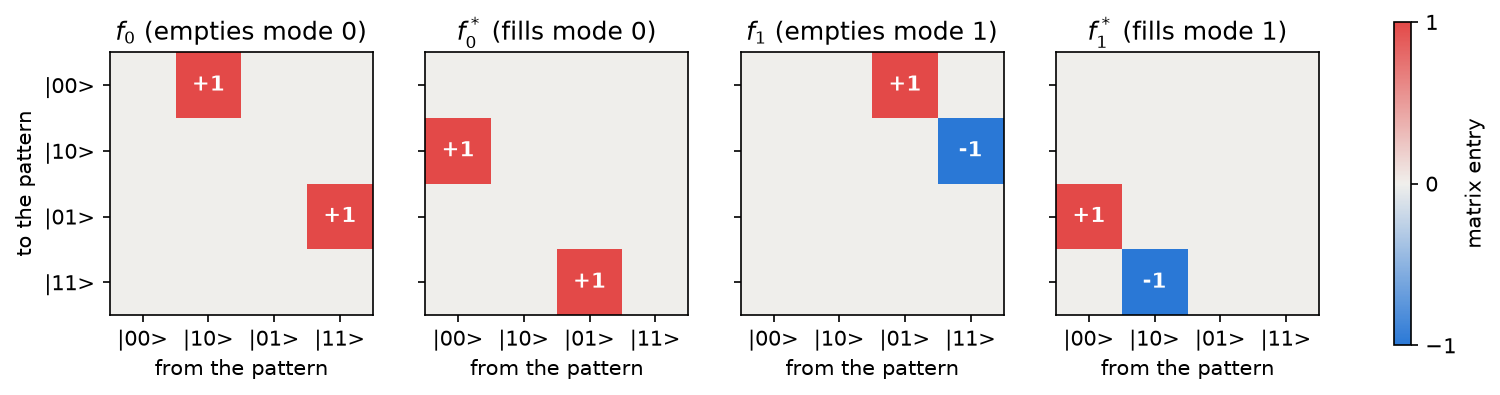

Figure 05e.1 saved as Revision/textbook/figures/05e_1_two_modes.png


In [5]:
from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])
PATTERNS = ["|00>", "|10>", "|01>", "|11>"]  # the patterns n = 0, 1, 2, 3
fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.5))
for k, (ax, matrix, title) in enumerate(zip(
        axes, [f2[0], f2_star[0], f2[1], f2_star[1]],
        ["$f_0$ (empties mode 0)", "$f_0^*$ (fills mode 0)",
         "$f_1$ (empties mode 1)", "$f_1^*$ (fills mode 1)"])):
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1, vmax=1)
    for r in range(4):
        for c in range(4):
            if matrix[r, c]:
                ax.text(c, r, f"{matrix[r, c]:+d}", ha="center", va="center",
                        color="white", fontweight="bold")
    ax.set_xticks(range(4), PATTERNS)
    # the row labels only on the first picture (the rows are the same in all four)
    ax.set_yticks(range(4), PATTERNS if k == 0 else [""] * 4)
    ax.set_xlabel("from the pattern")
    if k == 0:
        ax.set_ylabel("to the pattern")
    ax.set_title(title)
    ax.grid(False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "two_modes",
            "The annihilation and creation operators of two fermion modes as 4 by 4 "
            "matrices: column the pattern acted on, row the resulting pattern "
            "(00: both modes empty, 10: mode 0 full, 01: mode 1 full, 11: both "
            "full); red $+1$, blue $-1$, grey 0. Each operator moves one pattern "
            "to another; $f_1$ acting on the full pattern 11 gives $-1$ times the "
            "pattern 10, because mode 0 below it is occupied. This sign makes "
            "operators of different modes anticommute.")

## 7. Sixteen modes: the Fock space of 65536 states

The next cell defines the operators for 16 modes. A state is a dictionary
`{pattern: amplitude}`; `annihilate(p, state)` is $f_p$ and `create(p, state)` is
$f_p^*$, with the sign rule of section 6; `combine(terms)` adds up states with
coefficients; `inner(left, right)` is the ordinary (positive) inner product
$\langle\text{left}|\text{right}\rangle = \sum_n \text{left}_n^*\,\text{right}_n$;
`largest(state)` is the largest size of an amplitude. It then checks the canonical
relations $\{f_p, f_q^*\} = \delta_{pq}$ and $\{f_p, f_q\} = 0$ for all
$16 \times 16$ pairs on a random state: a dictionary with six random patterns and
random complex amplitudes, from the random-number generator with the fixed seed
12345 (so every run uses the same numbers).

In [6]:
def sign_below(n, p):
    """(-1) to the power of the number of occupied modes below mode p in pattern n."""
    return -1 if bin(n & ((1 << p) - 1)).count("1") % 2 else 1


def annihilate(p, state):
    """f_p applied to state: empties mode p (patterns with mode p empty give 0)."""
    result = {}
    for n, amplitude in state.items():
        if n >> p & 1:  # mode p is full in the pattern n
            new = n ^ (1 << p)  # the same pattern with mode p emptied
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def create(p, state):
    """f_p^* applied to state: fills mode p (patterns with mode p full give 0)."""
    result = {}
    for n, amplitude in state.items():
        if not n >> p & 1:  # mode p is empty in the pattern n
            new = n | (1 << p)  # the same pattern with mode p filled
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def combine(terms):
    """The state sum of coefficient * state over the pairs (coefficient, state)."""
    result = {}
    for coefficient, state in terms:
        for n, amplitude in state.items():
            result[n] = result.get(n, 0) + coefficient * amplitude
    return result


def inner(left, right):
    """The ordinary inner product <left|right> (positive: <s|s> >= 0)."""
    return sum(np.conj(a) * right.get(n, 0) for n, a in left.items())


def largest(state):
    """The largest size of an amplitude of state (0 for the zero state)."""
    return max((abs(a) for a in state.values()), default=0.0)


rng = np.random.default_rng(12345)  # random numbers with a fixed seed
RANDOM_STATE = {int(n): complex(rng.normal(), rng.normal())
                for n in rng.integers(0, 2 ** 16, size=6)}  # six random patterns
worst = 0.0  # the largest violation of a canonical relation
for p in range(16):
    for q in range(16):
        mixed = combine([(1, annihilate(p, create(q, RANDOM_STATE))),
                         (1, create(q, annihilate(p, RANDOM_STATE)))])
        expected = RANDOM_STATE if p == q else {}  # delta_pq times the state
        worst = max(worst, largest(combine([(1, mixed), (-1, expected)])))
        same = combine([(1, annihilate(p, annihilate(q, RANDOM_STATE))),
                        (1, annihilate(q, annihilate(p, RANDOM_STATE)))])
        worst = max(worst, largest(same))
say(f"patterns in the random state: {len(RANDOM_STATE)}; pairs tested: 2 x 256")
check(worst < 1e-12,
      "sixteen modes: {f_p, f_q^*} = delta_pq and {f_p, f_q} = 0 on a random state")

patterns in the random state: 6; pairs tested: 2 x 256
PASS sixteen modes: {f_p, f_q^*} = delta_pq and {f_p, f_q} = 0 on a random state


## 8. The quantised field of one good-sector momentum

The Revision record's exact Fock-space example has the mass $m = 3$ and the
momentum 4 along $x1$, so $E = \sqrt{3^2 + 4^2} = 5$; it has no extra-time
momentum (the *good sector*). It treats the metric near one point as flat
(constant gammas, no spin-connection term). Inserting $\Psi = u\,e^{i(k\,x1 -
E\,x4)}$ into $\gamma^{(x4)}\partial_{x4}\Psi + \gamma^{(x1)}\partial_{x1}\Psi =
m\Psi$ gives $-iE\gamma^{(x4)}u + ik\gamma^{(x1)}u = mu$; multiplying by
$-i\gamma^{(x4)}$ (with $\gamma^{(x4)}\gamma^{(x4)} = -1$) gives $Eu = hu$ with
the mode Hamiltonian $h = -im\gamma^{(x4)} - k\gamma^{(x4)}\gamma^{(x1)}$, here
with $k = 4$. Both matrices $-i\gamma^{(x4)}$ and $\gamma^{(x4)}\gamma^{(x1)}$ are
Hermitian ($\gamma^{(x4)}$ is real antisymmetric; $\gamma^{(x4)}\gamma^{(x1)}$ is
real symmetric), they anticommute,
and $(-i\gamma^{(x4)})^2 = (\gamma^{(x4)}\gamma^{(x1)})^2 = 1$, so $hh = (9 + 16)1
= 25\cdot 1$. The next cell builds $h$ and checks this, and finds orthonormal
eigenvectors $u_1, \dots, u_8$ ($hu_s = 5u_s$) and $v_1, \dots, v_8$
($hv_s = -5v_s$) as orthonormal columns of the projectors $\frac12(1 \pm h/E)$ (the
Gram-Schmidt procedure: subtract from each column its parts along the columns
already kept, divide by its length, keep it if the length is not zero). The 16
columns form the matrix $W$, with $W^\dagger W = WW^\dagger = 1$.

In [7]:
MASS, MOMENTUM = 3, 4  # the record's example: m = 3, momentum 4 along x1
E = float(np.sqrt(MASS ** 2 + MOMENTUM ** 2))  # the energy, 5
h = -1j * MASS * gamma["x4"] - MOMENTUM * (gamma["x4"] @ gamma["x1"])


def orthonormal_columns(P):
    """Orthonormal columns that span the range of P (Gram-Schmidt, done twice)."""
    basis = []
    for column in P.T:
        v = column.astype(complex)
        for _ in range(2):  # a second pass removes rounding errors
            for e in basis:
                v = v - (e.conj() @ v) * e  # remove the part along e
        length = np.sqrt((v.conj() @ v).real)
        if length > 1e-8:  # a new direction: keep it with length 1
            basis.append(v / length)
    return np.array(basis).T


U_plus = orthonormal_columns((np.eye(16) + h / E) / 2)  # u_1..u_8: energy +5
V_minus = orthonormal_columns((np.eye(16) - h / E) / 2)  # v_1..v_8: energy -5
W = np.hstack([U_plus, V_minus])  # 16 x 16: the columns u_1..u_8, v_1..v_8
report("E for m = 3 and momentum 4 along x1", f"{E:.12f}")
check(np.max(np.abs(h - h.conj().T)) < 1e-15
      and np.max(np.abs(h @ h - 25 * np.eye(16))) < 1e-13
      and U_plus.shape == (16, 8) and V_minus.shape == (16, 8)
      and np.max(np.abs(h @ U_plus - E * U_plus)) < 1e-13
      and np.max(np.abs(h @ V_minus + E * V_minus)) < 1e-13
      and np.max(np.abs(W.conj().T @ W - np.eye(16))) < 1e-13
      and np.max(np.abs(W @ W.conj().T - np.eye(16))) < 1e-13,
      "h is Hermitian, h h = 25, with 8 + 8 orthonormal complete eigenvectors")

RESULT E for m = 3 and momentum 4 along x1 = 5.000000000000
PASS h is Hermitian, h h = 25, with 8 + 8 orthonormal complete eigenvectors


**Operators as lists of 32 numbers.** Every operator that is a sum of single
$f$'s can be stored as 32 coefficients: of the 32 *basic operators* $O_i$,
$i = 0, \dots, 31$, where $O_p = F_p$ and $O_{16+p} = F_p^*$ for $p = 0, \dots, 15$,
with $F_p = b$ (that is $f_p$) for $p < 8$ and $F_p = d^*$ (that is $f_p^*$) for
$p \geq 8$, and $F_p^*$ the Hilbert adjoint of $F_p$. Then
$\Psi_A = \sum_p W_{Ap}F_p$ is the row `PSI[A]` $= (W_{A,0}, \dots, W_{A,15}, 0,
\dots, 0)$, its Hilbert adjoint $\chi_A = \sum_p W^*_{Ap}F_p^*$ is
`CHI[A]` $= (0, \dots, 0, W^*_{A,0}, \dots, W^*_{A,15})$, and $\Psi^\dagger_A =
\sum_C\chi_C B_{CA}$ is row $A$ of $B^T$ times `CHI`. The next cell defines these
rows, `apply(row, state)` (the operator of a row applied to a state) and
`anticommutator(row1, row2, state)`. It then measures, on the random state, the
numbers $\{\Psi_A, \chi_C\}$, $\{\Psi_A, \Psi^\dagger_C\}$, $\{\Psi_A, \Psi_C\}$
and $\{\Psi^\dagger_A, \Psi^\dagger_C\}$ for all $16 \times 16$ pairs: each
anticommutator must be a number times the state; the number is read off as
$\langle\phi|\{X, Y\}\phi\rangle/\langle\phi|\phi\rangle$ and the rest must vanish.

In [8]:
def basic(i, state):
    """The basic operator O_i applied to state: O_p = F_p, O_(16+p) = F_p^*."""
    p = i % 16  # the mode
    empties = (i < 16) == (p < 8)  # F_p for p < 8 and F_p^* for p >= 8 empty mode p
    return annihilate(p, state) if empties else create(p, state)


ZEROS = np.zeros((16, 16))
PSI = np.hstack([W, ZEROS])  # row A: Psi_A = sum_p W_Ap F_p
CHI = np.hstack([ZEROS, W.conj()])  # row A: chi_A = sum_p conj(W_Ap) F_p^*
PSI_DAG = B.T @ CHI  # row A: Psi^dagger_A = sum_C chi_C B_CA


def apply(row, state):
    """The operator sum_i row_i O_i applied to state."""
    return combine([(row[i], basic(i, state)) for i in range(32)
                    if abs(row[i]) > 1e-15])


def anticommutator(row1, row2, state):
    """{X, Y} applied to state, for the operators X and Y of the two rows."""
    return combine([(1, apply(row1, apply(row2, state))),
                    (1, apply(row2, apply(row1, state)))])


def measured_rule(rows1, rows2, state):
    """The 16 x 16 numbers {X_A, Y_C} = <state|{X_A, Y_C} state>/<state|state>, and
    the largest amplitude left over when that number times the state is removed."""
    norm = inner(state, state).real
    numbers = np.zeros((16, 16), dtype=complex)
    rest = 0.0
    for A in range(16):
        for C_ in range(16):
            result = anticommutator(rows1[A], rows2[C_], state)
            numbers[A, C_] = inner(state, result) / norm
            rest = max(rest, largest(combine([(1, result),
                                              (-numbers[A, C_], state)])))
    return numbers, rest


with_chi, rest_chi = measured_rule(PSI, CHI, RANDOM_STATE)
with_dagger, rest_dagger = measured_rule(PSI, PSI_DAG, RANDOM_STATE)
psi_psi, rest_pp = measured_rule(PSI, PSI, RANDOM_STATE)
dag_dag, rest_dd = measured_rule(PSI_DAG, PSI_DAG, RANDOM_STATE)
all_rest = max(rest_chi, rest_dagger, rest_pp, rest_dd)
say("every anticommutator is a number times the state (rest below 1e-12): "
    f"{all_rest < 1e-12}")
check_reproduces(np.max(np.abs(with_chi - np.eye(16))) < 1e-12
                 and np.max(np.abs(with_dagger - B)) < 1e-12
                 and np.max(np.abs(psi_psi)) < 1e-12
                 and np.max(np.abs(dag_dag)) < 1e-12 and all_rest < 1e-12
                 and recorded("wolfram", "Fock_space_good_sector_example"),
                 "{Psi_A, chi_C} = delta_AC and {Psi_A, Psi^dagger_C} = B_AC on the "
                 "positive Fock space; {Psi, Psi} = 0 = {Psi^dagger, Psi^dagger}",
                 record=record_of("wolfram", "Fock_space_good_sector_example"))

every anticommutator is a number times the state (rest below 1e-12): True
PASS {Psi_A, chi_C} = delta_AC and {Psi_A, Psi^dagger_C} = B_AC on the positive Fock
    space; {Psi, Psi} = 0 = {Psi^dagger, Psi^dagger}
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Fock_space_good_sector_example


The next cell draws the measured numbers $\{\Psi_A, \chi_C\}$ (real part; the
imaginary part is zero) and $\{\Psi_A, \Psi^\dagger_C\}$ (imaginary part; the real
part is zero) next to the imaginary part of $B$.

PASS the measured numbers are real for chi and imaginary for Psi^dagger


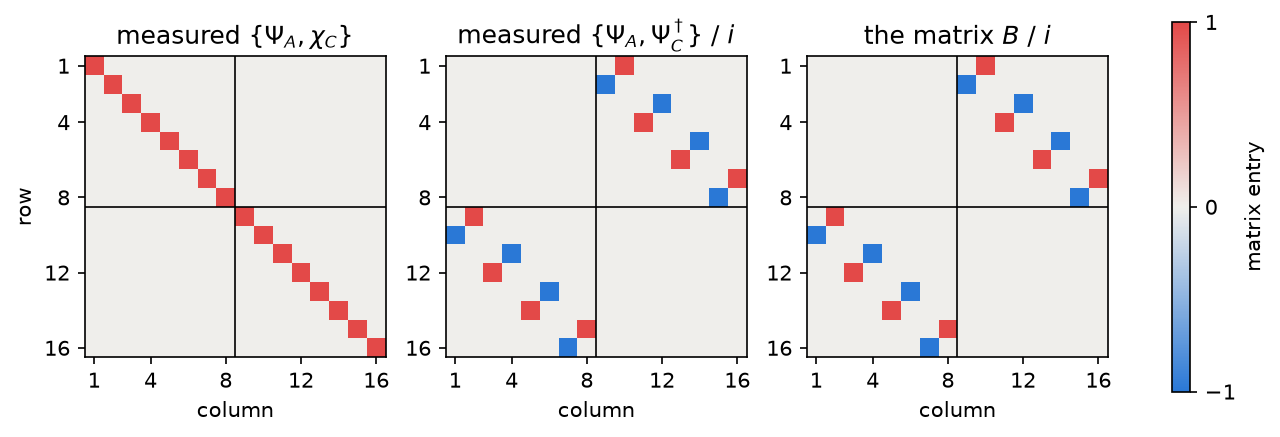

Figure 05e.2 saved as Revision/textbook/figures/05e_2_anticommutators.png


In [9]:
def heat_map(ax, matrix, title, row_label=True):
    """Draw a 16 x 16 matrix with entries from -1 to +1: blue -1, grey 0, red +1.
    Rows and columns are numbered from 1; black lines separate the two halves."""
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 3, 7, 11, 15], ["1", "4", "8", "12", "16"])
    ax.set_yticks([0, 3, 7, 11, 15], ["1", "4", "8", "12", "16"])
    ax.axhline(7.5, color="black", linewidth=0.8)
    ax.axvline(7.5, color="black", linewidth=0.8)
    ax.set_xlabel("column")
    if row_label:
        ax.set_ylabel("row")
    ax.grid(False)
    return image


check(np.max(np.abs(with_chi.imag)) < 1e-12 and np.max(np.abs(with_dagger.real))
      < 1e-12, "the measured numbers are real for chi and imaginary for Psi^dagger")
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
heat_map(axes[0], with_chi.real, r"measured $\{\Psi_A, \chi_C\}$")
heat_map(axes[1], with_dagger.imag, r"measured $\{\Psi_A, \Psi^\dagger_C\}$ / $i$",
         row_label=False)
image = heat_map(axes[2], B.imag, r"the matrix $B$ / $i$", row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "anticommutators",
            "The anticommutators of the quantised field measured on the Fock space "
            "of 65536 states, as 16 by 16 heat maps (row $A$, column $C$, from 1 to "
            "16; blue $-1$, grey 0, red $+1$): left $\\{\\Psi_A, \\chi_C\\}$ with the "
            "Hilbert adjoint $\\chi$, which is the identity matrix; middle "
            "$\\{\\Psi_A, \\Psi^\\dagger_C\\}$ with the canonical conjugate "
            "$\\Psi^\\dagger = \\chi B$, divided by $i$; right the matrix $B$ divided "
            "by $i$. The middle and right pictures are equal: the realisation obeys "
            "the canonical rule, and its diagonal is empty.")

## 9. Why the canonical conjugate is not the Hilbert adjoint

The record's check `no_positive_inner_product` uses the vector $u$ with
$u_7 = -i/\sqrt2$, $u_{16} = 1/\sqrt2$ and all other entries 0, which obeys
$Bu = -u$. The next cell checks $Bu = -u$ and $u^\dagger Bu = -1$, forms
$X = \sum_A u_A^*\Psi_A$ with its Hilbert adjoint $X^* = \sum_A u_A\chi_A$ and its
canonical conjugate $X^\dagger = \sum_A u_A\Psi^\dagger_A$, and measures
$\{X, X^*\} = +1$ (positive, as for every operator and its Hilbert adjoint) and
$\{X, X^\dagger\} = -1$ (negative): the canonical conjugate cannot be the adjoint of
a positive inner product. The cell also computes the 16 eigenvalues of $B$ (eight
$+1$, eight $-1$).

In [10]:
u = np.zeros(16, dtype=complex)
u[6], u[15] = -1j / np.sqrt(2), 1 / np.sqrt(2)  # u_7 and u_16 (Python counts from 0)
X_row = u.conj() @ PSI  # X = sum_A conj(u_A) Psi_A
X_adjoint = u @ CHI  # X^* = sum_A u_A chi_A (the Hilbert adjoint)
X_dagger = u @ PSI_DAG  # X^dagger = sum_A u_A Psi^dagger_A (canonical conjugate)
norm_random = inner(RANDOM_STATE, RANDOM_STATE).real
with_adjoint = inner(RANDOM_STATE, anticommutator(X_row, X_adjoint,
                                                  RANDOM_STATE)) / norm_random
with_canonical = inner(RANDOM_STATE, anticommutator(X_row, X_dagger,
                                                    RANDOM_STATE)) / norm_random
eigen_B = np.linalg.eigvalsh(B)  # the 16 eigenvalues of the Hermitian matrix B
say(f"{{X, X^*}} = {with_adjoint.real:+.6f};  {{X, X^dagger}} = "
    f"{with_canonical.real:+.6f};  u^dagger B u = {(u.conj() @ B @ u).real:+.6f}")
check_reproduces(np.allclose(B @ u, -u) and abs(u.conj() @ B @ u + 1) < 1e-12
                 and abs(with_adjoint - 1) < 1e-12 and abs(with_canonical + 1) < 1e-12
                 and recorded("wolfram", "no_positive_inner_product"),
                 "{X, X^*} = +1 but {X, X^dagger} = u^dagger B u = -1: the canonical "
                 "conjugate needs an indefinite (Krein) inner product",
                 record=record_of("wolfram", "no_positive_inner_product"))

{X, X^*} = +1.000000;  {X, X^dagger} = -1.000000;  u^dagger B u = -1.000000
PASS {X, X^*} = +1 but {X, X^dagger} = u^dagger B u = -1: the canonical conjugate needs
    an indefinite (Krein) inner product
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    no_positive_inner_product


The next cell draws the eigenvalues of $B$ and the two measured anticommutators.

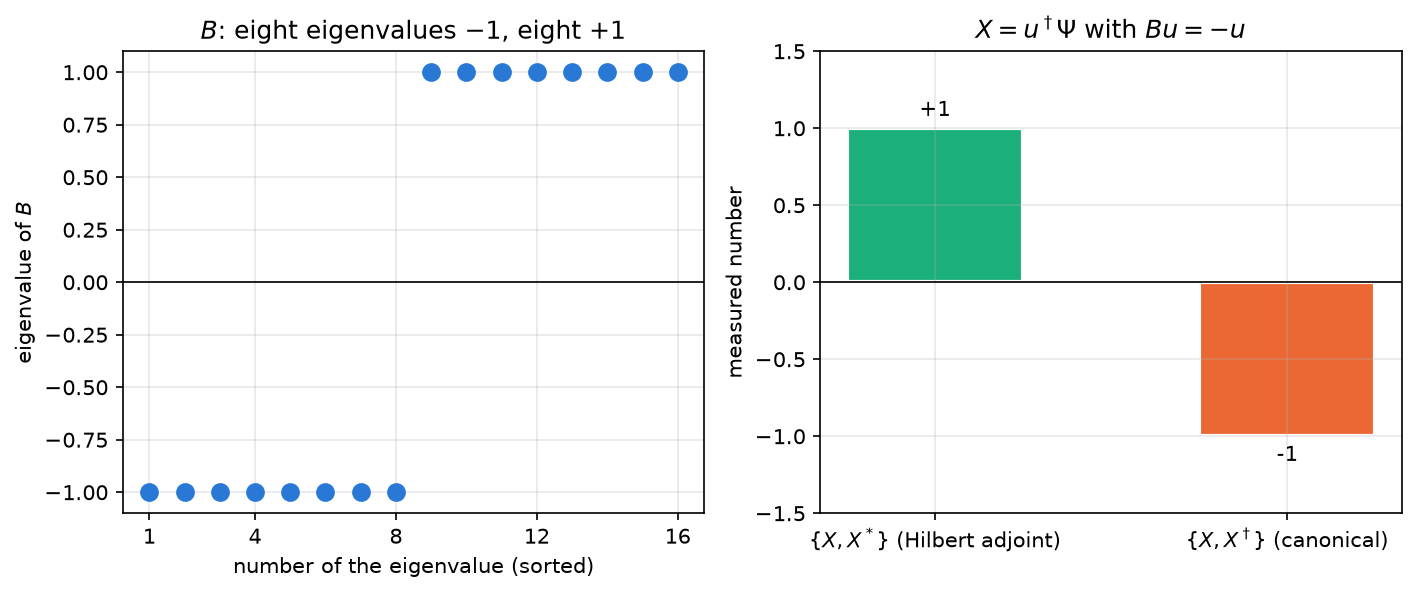

Figure 05e.3 saved as Revision/textbook/figures/05e_3_why_krein.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
axes[0].plot(np.arange(1, 17), eigen_B, "o", color="#2a78d6", markersize=8)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_xticks([1, 4, 8, 12, 16])
axes[0].set_xlabel("number of the eigenvalue (sorted)")
axes[0].set_ylabel("eigenvalue of $B$")
axes[0].set_title("$B$: eight eigenvalues $-1$, eight $+1$")
axes[1].bar([0, 1], [with_adjoint.real, with_canonical.real],
            color=["#1baf7a", "#eb6834"], edgecolor="white", linewidth=2, width=0.5)
for x_bar, value in zip([0, 1], [with_adjoint.real, with_canonical.real]):
    axes[1].text(x_bar, value + (0.08 if value > 0 else -0.16), f"{value:+.0f}",
                 ha="center")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xticks([0, 1], [r"$\{X, X^*\}$ (Hilbert adjoint)",
                            r"$\{X, X^\dagger\}$ (canonical)"])
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_ylabel("measured number")
axes[1].set_title("$X = u^\\dagger\\Psi$ with $Bu = -u$")
save_figure(fig, "why_krein",
            "Why the quantised field needs an indefinite (Krein) inner product. "
            "Left: the 16 eigenvalues of $B$, sorted (horizontal axis their number, "
            "vertical axis their value): eight are $-1$ and eight are $+1$. Right: "
            "for the operator $X = u^\\dagger\\Psi$ built from an eigenvector $u$ of "
            "$B$ with eigenvalue $-1$, the anticommutator with its Hilbert adjoint is "
            "$+1$ (green), as it must be for every operator in a space with a "
            "positive inner product, while the canonical rule gives $u^\\dagger Bu "
            "= -1$ (orange).")

## 10. The vacuum, the 16 quanta and the expectation-value rule

A **bilinear** $\sum_{A,C}L_A K_{AC}R_C$ of two operators with rows $L_A$, $R_C$
is $\sum_{i,j}Q_{ij}O_iO_j$ with the $32 \times 32$ matrix $Q = L^TKR$. The next
cell defines `bilinear(L, K, R, state)`, `vacuum_value` and `normal_ordered_value`
(the value in a state minus the vacuum value), and computes, as the record does:

- the energy $\chi h\Psi$: its vacuum value must be $-8E = -40$ (the filled sea),
  and after normal ordering each of the 16 quanta $b_s^*|0\rangle$, $d_s^*|0\rangle$
  must have the energy $+5$;
- the charge $J^{(x4)} = \Psi^\dagger B\Psi = \chi BB\Psi = \chi\Psi$: vacuum value 8;
  after normal ordering $+1$ for the 8 particles and $-1$ for the 8 antiparticles;
- the expectation-value rule of the record: $\langle q|:\!\Psi^\dagger M\Psi\!:|q
  \rangle = u_s^\dagger BMu_s$ for the particle $q = b_s^*|0\rangle$ and
  $-v_s^\dagger BMv_s$ for the antiparticle $q = d_s^*|0\rangle$, for the record's
  matrices $M = C$, $-iC\gamma^{(x4)}$ and $-iC\gamma^{(x1)}$.

In [12]:
VACUUM = {0: 1.0}  # the pattern 0: no particle, no antiparticle


def bilinear(L, K, R, state):
    """sum over A, C of L_A K_AC R_C applied to state (L, R: 16 rows of 32)."""
    Q = L.T @ K @ R  # 32 x 32: the coefficient of O_i O_j
    terms = []
    for j in range(32):
        if np.max(np.abs(Q[:, j])) > 1e-15:
            lowered = basic(j, state)  # O_j applied first
            if lowered:
                terms += [(Q[i, j], basic(i, lowered)) for i in range(32)
                          if abs(Q[i, j]) > 1e-15]
    return combine(terms)


def vacuum_value(L, K, R):
    """<0| sum L K R |0>."""
    return inner(VACUUM, bilinear(L, K, R, VACUUM))


QUANTA = [create(p, VACUUM) for p in range(16)]  # b_s^*|0> (p < 8), d_s^*|0>


def normal_ordered_value(L, K, R, state):
    """<state|X|state> - <0|X|0> for a normalised state."""
    return inner(state, bilinear(L, K, R, state)) - vacuum_value(L, K, R)


vacuum_energy = vacuum_value(CHI, h, PSI)
energies = np.array([normal_ordered_value(CHI, h, PSI, q) for q in QUANTA])
vacuum_charge = vacuum_value(PSI_DAG, B, PSI)
charges = np.array([normal_ordered_value(PSI_DAG, B, PSI, q) for q in QUANTA])
report("vacuum energy <0|chi h Psi|0> (the filled sea)", f"{vacuum_energy.real:.6f}")
report("vacuum charge <0|Psi^dagger B Psi|0>", f"{vacuum_charge.real:.6f}")
say("normal-ordered energies of the 16 quanta: "
    + " ".join(f"{e.real:+.0f}" for e in energies))
say("normal-ordered charges of the 16 quanta:  "
    + " ".join(f"{c.real:+.0f}" for c in charges))
rule_ok = True
for K_rule in [C, -1j * (C @ gamma["x4"]), -1j * (C @ gamma["x1"])]:
    values = [normal_ordered_value(PSI_DAG, K_rule, PSI, q) for q in QUANTA]
    predicted = ([W[:, s].conj() @ B @ K_rule @ W[:, s] for s in range(8)]
                 + [-(W[:, s].conj() @ B @ K_rule @ W[:, s]) for s in range(8, 16)])
    rule_ok &= np.max(np.abs(np.array(values) - np.array(predicted))) < 1e-12
check_reproduces(abs(vacuum_energy + 40) < 1e-12 and np.max(np.abs(energies - 5)) < 1e-12
                 and abs(vacuum_charge - 8) < 1e-12
                 and np.max(np.abs(charges - np.array([1] * 8 + [-1] * 8))) < 1e-12
                 and rule_ok and "-8 E" in detail("wolfram",
                                                  "Fock_space_good_sector_example"),
                 "vacuum energy -40, every quantum +5, charges +1 and -1, and the "
                 "expectation-value rule for M = C, -i C gamma^(x4), -i C gamma^(x1)",
                 record=record_of("wolfram", "Fock_space_good_sector_example"))

RESULT vacuum energy <0|chi h Psi|0> (the filled sea) = -40.000000
RESULT vacuum charge <0|Psi^dagger B Psi|0> = 8.000000
normal-ordered energies of the 16 quanta: +5 +5 +5 +5 +5 +5 +5 +5 +5 +5 +5 +5 +5 +5 +5 +5
normal-ordered charges of the 16 quanta:  +1 +1 +1 +1 +1 +1 +1 +1 -1 -1 -1 -1 -1 -1 -1 -1
PASS vacuum energy -40, every quantum +5, charges +1 and -1, and the expectation-value
    rule for M = C, -i C gamma^(x4), -i C gamma^(x1)
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Fock_space_good_sector_example


The next cell draws the energies and the charges of the 16 quanta before normal
ordering (the value in the state, which contains the vacuum value) and after it.

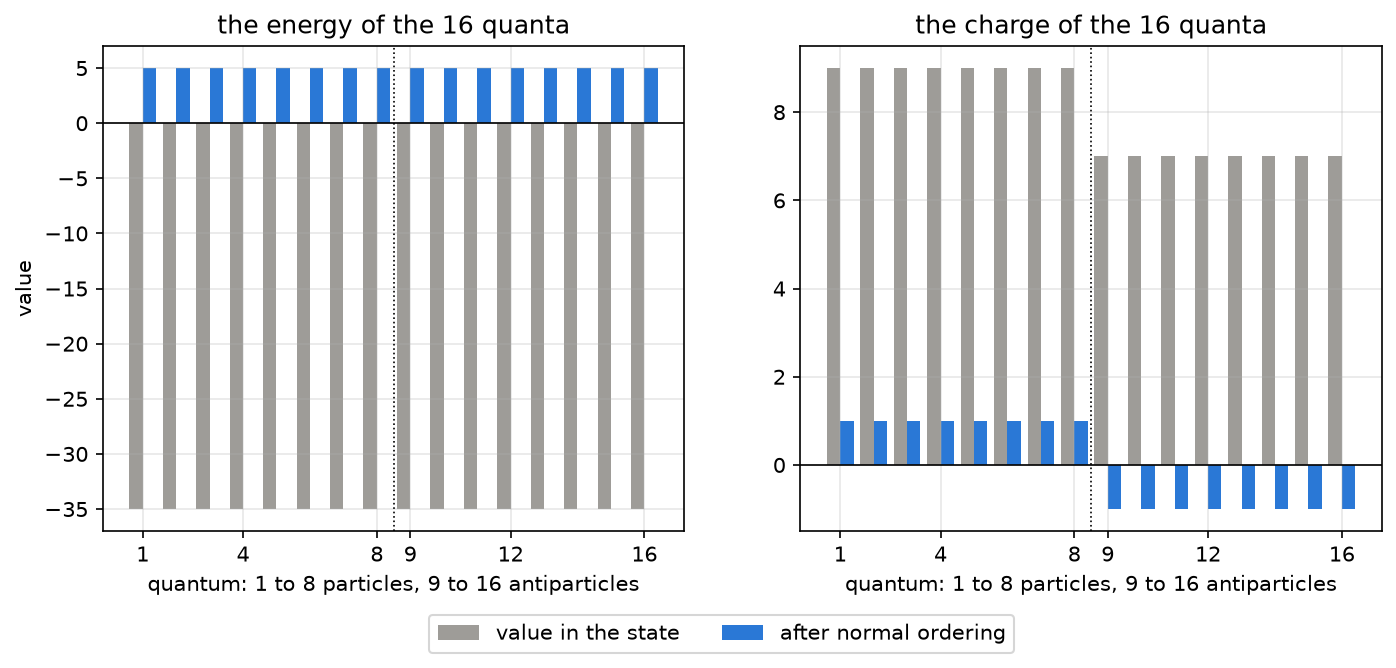

Figure 05e.4 saved as Revision/textbook/figures/05e_4_quanta.png


In [13]:
raw_energies = energies + vacuum_energy  # <q|chi h Psi|q>
raw_charges = charges + vacuum_charge  # <q|Psi^dagger B Psi|q>
index = np.arange(1, 17)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for ax, raw, ordered, name in [(axes[0], raw_energies, energies, "energy"),
                               (axes[1], raw_charges, charges, "charge")]:
    ax.bar(index - 0.2, raw.real, 0.4, color="#9e9c98", label="value in the state")
    ax.bar(index + 0.2, ordered.real, 0.4, color="#2a78d6",
           label="after normal ordering")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.axvline(8.5, color="black", linewidth=0.8, linestyle=":")
    ax.set_xticks([1, 4, 8, 9, 12, 16])
    ax.set_xlabel("quantum: 1 to 8 particles, 9 to 16 antiparticles")
    ax.set_title(f"the {name} of the 16 quanta")
axes[0].set_ylabel("value")
handles, names = axes[0].get_legend_handles_labels()  # one legend for both
fig.legend(handles, names, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=2)
save_figure(fig, "quanta",
            "The energy $\\chi h\\Psi$ (left) and the charge $\\Psi^\\dagger B\\Psi$ "
            "(right) of the 16 one-quantum states $b_s^{\\ast}|0\\rangle$ (numbers 1 "
            "to 8) and $d_s^{\\ast}|0\\rangle$ (9 to 16) for the record's example "
            "$m = 3$, "
            "momentum 4, $E = 5$: grey the value in the state, which contains the "
            "vacuum value ($-40$ for the energy, the filled sea, and $8$ for the "
            "charge), blue the value after normal ordering. After normal ordering "
            "every quantum has the energy $+5$; particles have the charge $+1$, "
            "antiparticles $-1$.")

## 11. The two conjugations of the quantised field

The next cell builds the conjugated operators of section 4 for $M = 1$ and
$M = \Gamma$: the rows of $\Psi'_A = \sum_C M_{AC}\Psi^\dagger_C$ are `M @ PSI_DAG`
and those of $\Psi'^\dagger_A = \sum_C M^*_{AC}\Psi_C$ are `M.conj() @ PSI`. It
measures $\{\Psi'_A, \Psi'^\dagger_C\}$ on the random state and compares with
$MB^TM^\dagger$, which the Revision record computed: $-B$ for $M = 1$ (the rule is
broken) and $+B$ for $M = \Gamma$ (the rule is kept).

In [14]:
MAPS = {"M = 1": I16, "M = Gamma": Gamma}  # the two conjugation matrices
conjugated = {}  # name -> (rows of Psi', rows of Psi'^dagger)
measured_conjugated = {}  # name -> the measured {Psi'_A, Psi'^dagger_C}
for name, M in MAPS.items():
    rows_prime = M @ PSI_DAG  # Psi'_A = sum_C M_AC Psi^dagger_C
    rows_prime_dagger = M.conj() @ PSI  # Psi'^dagger_A = sum_C conj(M_AC) Psi_C
    conjugated[name] = (rows_prime, rows_prime_dagger)
    numbers, rest = measured_rule(rows_prime, rows_prime_dagger, RANDOM_STATE)
    measured_conjugated[name] = numbers
    predicted = M @ B.T @ M.conj().T
    say(f"{name:9}: measured equals M B^T M^dagger: "
        f"{np.max(np.abs(numbers - predicted)) < 1e-12 and rest < 1e-12}; "
        f"it equals +B: {np.max(np.abs(numbers - B)) < 1e-12}; "
        f"-B: {np.max(np.abs(numbers + B)) < 1e-12}")
check_reproduces(np.max(np.abs(measured_conjugated["M = 1"] + B)) < 1e-12
                 and np.max(np.abs(measured_conjugated["M = Gamma"] - B)) < 1e-12
                 and recorded("lead", "quantum_charge_conjugation_unitary_type"),
                 "on the Fock space: Psi' = Psi^(dagger T) gives -B, Psi' = Gamma "
                 "Psi^(dagger T) gives +B: only M = Gamma keeps the canonical rule",
                 record=record_of("lead", "quantum_charge_conjugation_unitary_type"))

M = 1    : measured equals M B^T M^dagger: True; it equals +B: False; -B: True
M = Gamma: measured equals M B^T M^dagger: True; it equals +B: True; -B: False
PASS on the Fock space: Psi' = Psi^(dagger T) gives -B, Psi' = Gamma Psi^(dagger T) gives
    +B: only M = Gamma keeps the canonical rule
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    quantum_charge_conjugation_unitary_type


The next cell draws the two measured rules next to $B$.

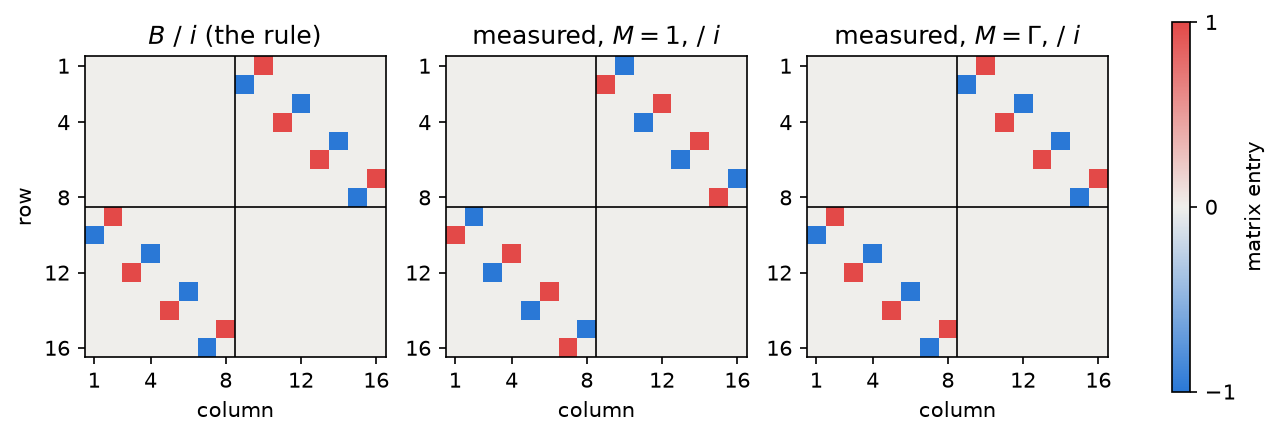

Figure 05e.5 saved as Revision/textbook/figures/05e_5_conjugated_rules.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
heat_map(axes[0], B.imag, r"$B$ / $i$ (the rule)")
heat_map(axes[1], measured_conjugated["M = 1"].imag,
         r"measured, $M = 1$, / $i$", row_label=False)
image = heat_map(axes[2], measured_conjugated["M = Gamma"].imag,
                 r"measured, $M = \Gamma$, / $i$", row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "conjugated_rules",
            "The canonical rule after the two conjugations, measured on the Fock "
            "space: the numbers $\\{\\Psi'_A, \\Psi'^\\dagger_C\\}$ divided by $i$ "
            "for $\\Psi' = \\Psi^{\\dagger T}$ (middle, the type of the same-mass "
            "matrix $\\mathcal{C}_+$) and $\\Psi' = \\Gamma\\Psi^{\\dagger T}$ "
            "(right, the type of the mass-reversing matrix $\\mathcal{C}_-$), next "
            "to $B$ divided by $i$ (left); row $A$ and column $C$ from 1 to 16; blue "
            "$-1$, grey 0, red $+1$. The middle picture has every colour reversed "
            "($-B$): that map breaks the rule. The right picture equals the left "
            "one: only $\\Gamma$ gives a conjugation of the quantised field.")

## 12. The conjugated bilinears: a sign and a constant

The next cell computes, for the scalar ($K = C$) and the eight currents
($K = -iC\gamma^a$) and for both maps, the conjugated operator $X' =
\Psi'^\dagger K\Psi'$ and the original $X = \Psi^\dagger K\Psi$, both applied to
the random state, and finds the sign $s$ and the number $c$ with $X' = sX + c$.
Section 4 predicts $c = \mathrm{tr}(K'B^T)$ with $K' = M^\dagger KM$, and $s$ from
$-(M^\dagger KM)^T = sK$. The cell compares the measured signs with the table that
the Revision record measured for classical *anticommuting* components (its keys
`plus,eps=-1` and `minus,eps=-1`, stored in the detail text after the word
measured).

In [16]:
K_MATRICES = {"S": C.astype(complex)}  # the scalar S = Psi^dagger C Psi
for x in COORDS:
    K_MATRICES[f"J^({x})"] = -1j * (C @ gamma[x])  # the current J^a
BILINEAR_NAMES = list(K_MATRICES)  # "S", "J^(x1)", ..., "J^(x8)"
signs, constants = {}, {}  # (map, bilinear) -> s and c
identity_ok = True
for map_name, M in MAPS.items():
    rows_prime, rows_prime_dagger = conjugated[map_name]
    for bname, K in K_MATRICES.items():
        K_prime = M.conj().T @ K @ M  # K' = M^dagger K M
        c = np.trace(K_prime @ B.T)  # the predicted constant
        s = 1 if np.array_equal(-K_prime.T, K) else (
            -1 if np.array_equal(-K_prime.T, -K) else 0)  # -K'^T = s K
        X_prime = bilinear(rows_prime_dagger, K, rows_prime, RANDOM_STATE)
        X = bilinear(PSI_DAG, K, PSI, RANDOM_STATE)
        difference = combine([(1, X_prime), (-s, X), (-c, RANDOM_STATE)])
        identity_ok &= s != 0 and largest(difference) < 1e-10
        signs[(map_name, bname)], constants[(map_name, bname)] = s, c
for map_name in MAPS:
    say(f"{map_name:9}: s = " + " ".join(f"{signs[(map_name, b)]:+d}"
                                        for b in BILINEAR_NAMES)
        + "  (S, J^(x1), ..., J^(x8))")
    say(f"{'':9}  c = " + " ".join(f"{constants[(map_name, b)].real:+.0f}"
                                   for b in BILINEAR_NAMES))
lead_detail = detail("lead", "bilinears_under_charge_conjugation")
recorded_table = json.loads(lead_detail.split("measured: ", 1)[1])
anticommuting_rows = {"M = 1": recorded_table["plus,eps=-1"],
                      "M = Gamma": recorded_table["minus,eps=-1"]}
rows_agree = all([signs[(m_name, "S")], [signs[(m_name, b)] for b in
                                         BILINEAR_NAMES[1:]]] == row
                 for m_name, row in anticommuting_rows.items())
check(identity_ok, "X' = s X + c holds on the Fock space for all 9 bilinears and both "
      "maps, with c = tr(K' B^T)")
check_reproduces(rows_agree and recorded("lead", "bilinears_under_charge_conjugation"),
                 "the operator signs s equal the measured signs of the anticommuting "
                 "rows (eps = -1) of the recorded table",
                 record=record_of("lead", "bilinears_under_charge_conjugation"))

M = 1    : s = -1 +1 +1 +1 +1 +1 +1 +1 +1  (S, J^(x1), ..., J^(x8))
           c = +0 +0 +0 +0 -16 +0 +0 +0 +0
M = Gamma: s = -1 -1 -1 -1 -1 -1 -1 -1 -1  (S, J^(x1), ..., J^(x8))
           c = +0 +0 +0 +0 +16 +0 +0 +0 +0
PASS X' = s X + c holds on the Fock space for all 9 bilinears and both maps, with c =
    tr(K' B^T)
PASS the operator signs s equal the measured signs of the anticommuting rows (eps = -1)
    of the recorded table
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    bilinears_under_charge_conjugation


The number $c$ is zero for every bilinear except the charge density $J^{(x4)}$
(whose matrix $-iC\gamma^{(x4)}$ is $B$): there $c = \mathrm{tr}(BB^T) = -\mathrm{tr}
(BB) = -16$ for $M = 1$ and $+16$ for $M = \Gamma$. The next cell checks this and
computes the vacuum values $\langle 0|X|0\rangle$ and $\langle 0|X'|0\rangle$ of all
bilinears: they obey $\langle 0|X'|0\rangle = s\langle 0|X|0\rangle + c$. Then it
draws them.

PASS c = 0 except for the charge density J^(x4): c = -16 (M = 1), +16 (M = Gamma)
vacuum values <0|X|0>: S -4.80, J^(x1) -6.40, J^(x2) +0.00, J^(x3) +0.00, J^(x4) +8.00,
    J^(x5) +0.00, J^(x6) +0.00, J^(x7) +0.00, J^(x8) +0.00
PASS <0|X'|0> = s <0|X|0> + c for all 9 bilinears and both maps


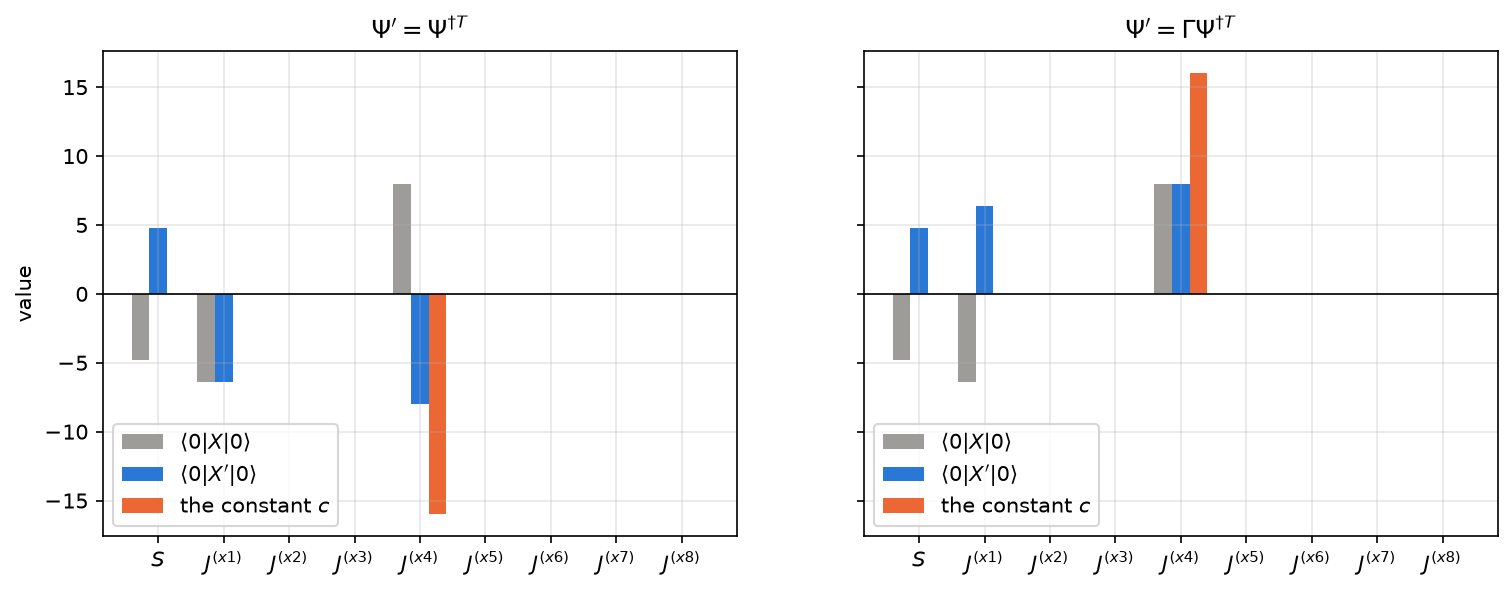

Figure 05e.6 saved as Revision/textbook/figures/05e_6_vacuum_values.png


In [17]:
nonzero = sorted({b for (m_name, b), c in constants.items() if abs(c) > 1e-12})
check(nonzero == ["J^(x4)"] and abs(constants[("M = 1", "J^(x4)")] + 16) < 1e-12
      and abs(constants[("M = Gamma", "J^(x4)")] - 16) < 1e-12,
      "c = 0 except for the charge density J^(x4): c = -16 (M = 1), +16 (M = Gamma)")
vac_original = {b: vacuum_value(PSI_DAG, K, PSI) for b, K in K_MATRICES.items()}
vac_conjugated = {}  # (map, bilinear) -> <0|X'|0>
for map_name in MAPS:
    rows_prime, rows_prime_dagger = conjugated[map_name]
    for bname, K in K_MATRICES.items():
        vac_conjugated[(map_name, bname)] = vacuum_value(rows_prime_dagger, K,
                                                         rows_prime)
# values below 1e-12 are printed as 0 (rounding could otherwise print "-0.00")
shown = {b: (v.real if abs(v) > 1e-12 else 0.0) for b, v in vac_original.items()}
say("vacuum values <0|X|0>: " + ", ".join(f"{b} {shown[b]:+.2f}"
                                         for b in BILINEAR_NAMES))
check(all(abs(vac_conjugated[key] - signs[key] * vac_original[key[1]]
              - constants[key]) < 1e-12 for key in vac_conjugated),
      "<0|X'|0> = s <0|X|0> + c for all 9 bilinears and both maps")
positions = np.arange(len(BILINEAR_NAMES))
labels = ["$S$"] + [rf"$J^{{({x})}}$" for x in COORDS]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
for ax, map_name, title in [(axes[0], "M = 1", r"$\Psi' = \Psi^{\dagger T}$"),
                            (axes[1], "M = Gamma",
                             r"$\Psi' = \Gamma\Psi^{\dagger T}$")]:
    ax.bar(positions - 0.27, [vac_original[b].real for b in BILINEAR_NAMES], 0.27,
           color="#9e9c98", label=r"$\langle 0|X|0\rangle$")
    ax.bar(positions, [vac_conjugated[(map_name, b)].real for b in BILINEAR_NAMES],
           0.27, color="#2a78d6", label=r"$\langle 0|X'|0\rangle$")
    ax.bar(positions + 0.27, [constants[(map_name, b)].real for b in BILINEAR_NAMES],
           0.27, color="#eb6834", label="the constant $c$")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xticks(positions, labels)
    ax.set_title(title)
    ax.legend(loc="lower left")
axes[0].set_ylabel("value")
save_figure(fig, "vacuum_values",
            "Vacuum values of the nine bilinears (horizontal axis: the scalar $S$ "
            "and the currents $J^a$) before the conjugation (grey) and after it "
            "(blue), and the constant $c$ of the identity $X' = sX + c$ (orange), "
            "for the conjugation with $M = 1$ (left) and $M = \\Gamma$ (right); "
            "vertical axis the value (a pure number). The filled sea gives nonzero "
            "vacuum values; $c$ vanishes except for the charge density $J^{(x4)}$, "
            "where it is $-16$ or $+16$. Normal ordering subtracts each operator's "
            "own vacuum value, which removes $c$.")

## 13. After normal ordering: the sign table of the quantised field

The next cell normal-orders both sides, $:\!X\!: = X - \langle 0|X|0\rangle$ and
$:\!X'\!: = X' - \langle 0|X'|0\rangle$, and checks $:\!X'\!: = s\,:\!X\!:$ on the
random state and on the 16 one-quantum states, for all bilinears and both maps.
It then computes, as the Revision record does, the classical tables:
$\epsilon(M^\dagger KM)^T$ compared with $K$, for commuting ($\epsilon = +1$) and
anticommuting ($\epsilon = -1$) components, and draws three tables: commuting,
anticommuting and the quantised field after normal ordering.

**About a remark in the record.** The detail text of the record's check
`bilinears_under_charge_conjugation` adds in parentheses that in the quantum theory
normal ordering supplies one more sign for each bilinear, which would give
$(S, J) \to (S, -J)$ for $\mathcal{C}_+$. That remark is not part of the record's
measured table, and this computation contradicts it: normal ordering removes
only the constant $c$, and the operator signs are exactly the measured signs of
the anticommuting rows.

PASS :X': = s :X: for all 9 bilinears, both maps, on the random state and the 16 quanta
PASS after normal ordering the quantised field has the signs of the anticommuting
    components; the commuting ones are the opposite


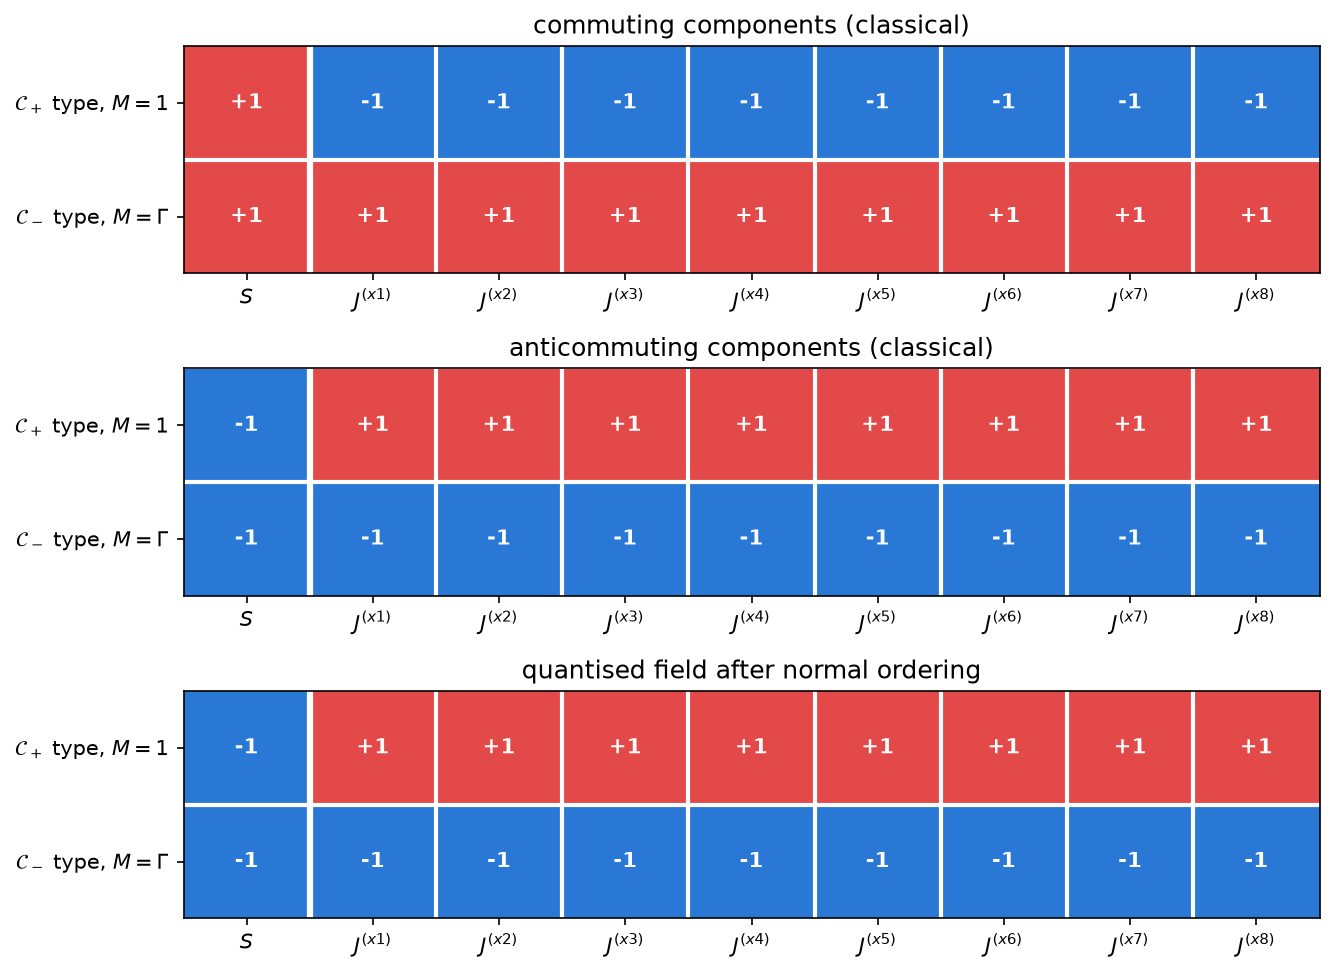

Figure 05e.7 saved as Revision/textbook/figures/05e_7_sign_tables.png


In [18]:
def apply_normal_ordered(L, K, R, state):
    """:X: = X - <0|X|0> applied to state."""
    return combine([(1, bilinear(L, K, R, state)),
                    (-vacuum_value(L, K, R), state)])


normal_ok = True
for map_name in MAPS:
    rows_prime, rows_prime_dagger = conjugated[map_name]
    for bname, K in K_MATRICES.items():
        for state in [RANDOM_STATE] + QUANTA:
            left = apply_normal_ordered(rows_prime_dagger, K, rows_prime, state)
            right = apply_normal_ordered(PSI_DAG, K, PSI, state)
            normal_ok &= largest(combine([(1, left),
                                          (-signs[(map_name, bname)], right)])) < 1e-10
check(normal_ok, ":X': = s :X: for all 9 bilinears, both maps, on the random state "
      "and the 16 quanta")


def classical_sign(M, K, eps):
    """+1 if eps (M^dagger K M)^T = K, -1 if it equals -K, 0 otherwise."""
    new = eps * (M.conj().T @ K @ M).T
    return 1 if np.array_equal(new, K) else (-1 if np.array_equal(new, -K) else 0)


tables = {"commuting components (classical)": 1,
          "anticommuting components (classical)": -1}
grids = {}
for title, eps in tables.items():
    grids[title] = np.array([[classical_sign(M, K_MATRICES[b], eps)
                              for b in BILINEAR_NAMES] for M in MAPS.values()])
grids["quantised field after normal ordering"] = np.array(
    [[signs[(m_name, b)] for b in BILINEAR_NAMES] for m_name in MAPS])
check(np.array_equal(grids["quantised field after normal ordering"],
                     grids["anticommuting components (classical)"])
      and np.array_equal(grids["commuting components (classical)"],
                         -grids["anticommuting components (classical)"]),
      "after normal ordering the quantised field has the signs of the anticommuting "
      "components; the commuting ones are the opposite")
fig, axes = plt.subplots(3, 1, figsize=(9.0, 6.6))
for ax, (title, grid) in zip(axes, grids.items()):
    ax.imshow(grid, cmap=SIGNS, vmin=-1, vmax=1, aspect="auto")
    for r in range(2):
        for c_col in range(9):
            ax.text(c_col, r, f"{grid[r, c_col]:+d}", ha="center", va="center",
                    color="white", fontweight="bold")
    ax.axhline(0.5, color="white", linewidth=2)
    for k in range(1, 9):
        ax.axvline(k - 0.5, color="white", linewidth=3 if k == 1 else 2)
    ax.set_xticks(range(9), labels)
    ax.set_yticks([0, 1], [r"$\mathcal{C}_+$ type, $M = 1$",
                           r"$\mathcal{C}_-$ type, $M = \Gamma$"])
    ax.set_title(title)
    ax.grid(False)
fig.tight_layout()
save_figure(fig, "sign_tables",
            "The sign that the scalar $S$ and the eight currents $J^a$ (columns) "
            "acquire under the two conjugations (rows: $M = 1$, the type of "
            "$\\mathcal{C}_+$, and $M = \\Gamma$, the type of $\\mathcal{C}_-$); red "
            "$+1$ kept, blue $-1$ reversed. Top: classical commuting components; "
            "middle: classical anticommuting components (the two tables measured "
            "by the Revision record); bottom: the quantised field, computed as "
            "operators on the Fock space and normal ordered. The bottom table "
            "equals the middle one: normal ordering adds no sign.")

## 14. What the allowed conjugation does to the charges of the quanta

Of the two maps, only $M = \Gamma$ keeps the canonical rule (section 11). The next
cell evaluates the normal-ordered charge density $:\!J^{(x4)}\!:$ and its two
conjugates
$:\!J'^{(x4)}\!:$ in the 16 one-quantum states. With $M = \Gamma$ every charge is
reversed (particles $+1 \to -1$, antiparticles $-1 \to +1$); with $M = 1$ (which
breaks the rule) the charges are unchanged.

PASS M = Gamma reverses the normal-ordered charge of every quantum; M = 1 keeps it


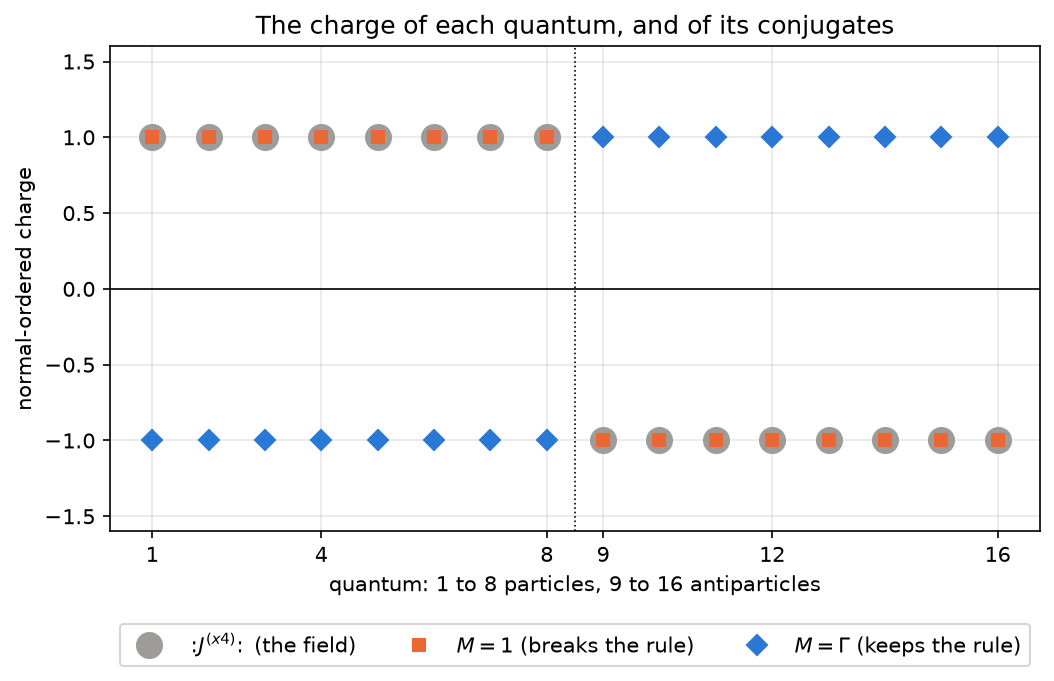

Figure 05e.8 saved as Revision/textbook/figures/05e_8_conjugated_charges.png


In [19]:
K_charge = K_MATRICES["J^(x4)"]  # equal to B
charge_values = {"original": charges.real}
for map_name in MAPS:
    rows_prime, rows_prime_dagger = conjugated[map_name]
    charge_values[map_name] = np.array(
        [normal_ordered_value(rows_prime_dagger, K_charge, rows_prime, q).real
         for q in QUANTA])
check(np.array_equal(K_charge, B)
      and np.max(np.abs(charge_values["M = Gamma"] + charges.real)) < 1e-12
      and np.max(np.abs(charge_values["M = 1"] - charges.real)) < 1e-12,
      "M = Gamma reverses the normal-ordered charge of every quantum; M = 1 keeps it")
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(index, charge_values["original"], "o", color="#9e9c98", markersize=12,
        label=r"$:\!J^{(x4)}\!:$ (the field)")
ax.plot(index, charge_values["M = 1"], "s", color="#eb6834", markersize=6,
        label=r"$M = 1$ (breaks the rule)")
ax.plot(index, charge_values["M = Gamma"], "D", color="#2a78d6", markersize=7,
        label=r"$M = \Gamma$ (keeps the rule)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(8.5, color="black", linewidth=0.8, linestyle=":")
ax.set_xticks([1, 4, 8, 9, 12, 16])
ax.set_ylim(-1.6, 1.6)
ax.set_xlabel("quantum: 1 to 8 particles, 9 to 16 antiparticles")
ax.set_ylabel("normal-ordered charge")
ax.set_title("The charge of each quantum, and of its conjugates")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3)
save_figure(fig, "conjugated_charges",
            "The normal-ordered charge density in each of the 16 one-quantum states "
            "(horizontal axis: 1 to 8 particles, 9 to 16 antiparticles; vertical axis "
            "the charge, a pure number): the field itself (grey circles: $+1$ for "
            "particles, $-1$ for antiparticles), the conjugate with $M = 1$ (orange "
            "squares, on the grey circles: unchanged) and the conjugate with $M = "
            "\\Gamma$ (blue diamonds: every charge reversed). The one of the two "
            "conjugations that keeps the canonical rule, $\\Psi \\to "
            "\\Gamma\\Psi^{\\dagger T}$, "
            "reverses the charge (and, as the Revision record states, the mass).")

## 15. The last check

The last cell checks that the eight figure files exist and prints the number of
checks that passed.

In [20]:
FIGURES = ["05e_1_two_modes.png", "05e_2_anticommutators.png", "05e_3_why_krein.png",
           "05e_4_quanta.png", "05e_5_conjugated_rules.png",
           "05e_6_vacuum_values.png", "05e_7_sign_tables.png",
           "05e_8_conjugated_charges.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in FIGURES),
      "the eight figure files of notebook 05e exist")
all_checks_passed()

PASS the eight figure files of notebook 05e exist
ALL 18 CHECKS PASSED (notebook 05e)


## 16. What this notebook showed

- PROVED (section 4, line by line) and COMPUTED (on the Fock space of 65536
  states): for the quantised field, the conjugated bilinear is
  $X' = \Psi^\dagger\big(-(M^\dagger KM)^T\big)\Psi + \mathrm{tr}(M^\dagger KMB^T)$:
  the rule of classical anticommuting components plus a constant.
- COMPUTED, reproducing the Revision record: the positive realisation
  $\Psi^\dagger = \chi B$ obeys $\{\Psi_A, \chi_C\} = \delta_{AC}$ and
  $\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$; the canonical conjugate cannot be a Hilbert
  adjoint ($\{X, X^\dagger\} = -1$); the vacuum energy is $-8E = -40$, every quantum
  has the energy $+5$ after normal ordering, particles have the charge $+1$ and
  antiparticles $-1$; the expectation-value rule holds.
- COMPUTED, reproducing the lead record: $\Psi \to \Psi^{\dagger T}$ turns the
  canonical rule into $-B$, $\Psi \to \Gamma\Psi^{\dagger T}$ keeps it.
- COMPUTED: the operator signs equal the measured signs of the anticommuting rows
  of the record's table: $M = 1$ gives $(S, J) \to (-S, +J)$, $M = \Gamma$ gives
  $(S, J) \to (-S, -J)$. The constant $c$ vanishes except for the charge density
  ($\mp 16$), and normal ordering removes it: after normal ordering the quantised
  field has exactly the anticommuting signs. The record's parenthetical remark
  that normal ordering supplies one more sign is contradicted by this
  computation.
- COMPUTED: of the two conjugations, the one that keeps the canonical rule,
  $\Psi \to \Gamma\Psi^{\dagger T}$ (among the multiples of 1 and of $\Gamma$ the
  only one, up to a phase factor), reverses the normal-ordered charge of every
  quantum.
- SCOPE: one momentum without extra-time part, at one point of space, with the
  metric treated as flat near that point; the vacuum is the Fock vacuum of that
  momentum. The sign argument of section 4 uses only the
  canonical rule and the subtraction of a number, so it does not depend on these
  choices.